# Imports ....

In [2]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

nnfs.init()

# Data

In [3]:
# ============================================================
# DATA
# ============================================================

X, y = spiral_data(samples=1000, classes=3)

# PLot the data 

X shape: (3000, 2)
y shape: (3000,)


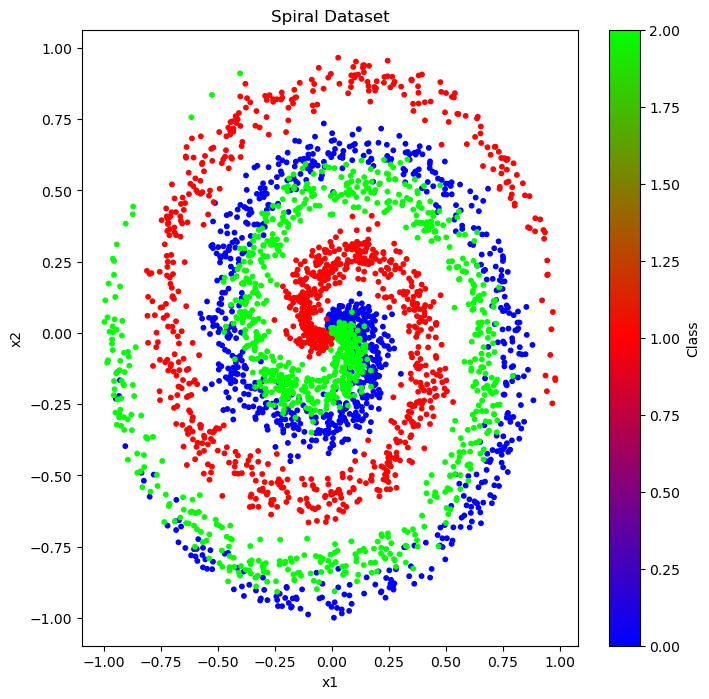

In [25]:
print("X shape:", X.shape)
print("y shape:", y.shape)

# scatter plot
plt.figure(figsize=(8,8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg",
    s=10
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Spiral Dataset")

plt.colorbar(label="Class")

plt.show()

# One hot encode ...

In [4]:
# ============================================================
# ONE HOT
# ============================================================

def one_hot(y, num_classes):

    return np.eye(num_classes)[y]

y_onehot = one_hot(y, 3)

# Neural Network parameters ...

In [5]:


INPUT_DIM = 2
HIDDEN_DIM = 64
OUTPUT_DIM = 3


# Initialize the weights and biases randomly ...

In [6]:
# ============================================================
# INITIALIZE PARAMETERS
# ============================================================

def init_params():

    params = {

        "W1": 0.01 * np.random.randn(INPUT_DIM, HIDDEN_DIM),
        "b1": np.zeros((1, HIDDEN_DIM)),

        "W2": 0.01 * np.random.randn(HIDDEN_DIM, OUTPUT_DIM),
        "b2": np.zeros((1, OUTPUT_DIM))
    }

    return params

# Activation functions 

In [7]:
# ============================================================
# ACTIVATIONS
# ============================================================

def relu(x):

    return np.maximum(0, x)

def relu_derivative(x):

    return (x > 0).astype(float)

def softmax(x):

    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Forward Pass

In [8]:
# ============================================================
# FORWARD PASS
# ============================================================

def forward(X, params):

    Z1 = X @ params["W1"] + params["b1"]

    A1 = relu(Z1)

    Z2 = A1 @ params["W2"] + params["b2"]

    A2 = softmax(Z2)

    cache = {

        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

# Loss function 

In [9]:
# ============================================================
# LOSS
# ============================================================

def cross_entropy(y_pred, y_true):

    y_pred = np.clip(y_pred, 1e-8, 1-1e-8)

    loss = -np.sum(y_true * np.log(y_pred)) / len(y_true)

    return loss

# BackPropagation 

In [10]:
# ============================================================
# BACKPROP
# ============================================================

def backward(X, y_true, params, cache):

    m = len(X)

    A1 = cache["A1"]
    A2 = cache["A2"]
    Z1 = cache["Z1"]

    dZ2 = (A2 - y_true) / m

    dW2 = A1.T @ dZ2

    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ params["W2"].T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1

    db1 = np.sum(dZ1, axis=0, keepdims=True)

    grads = {

        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2
    }

    return grads

# Accuracy 

In [11]:
# ============================================================
# ACCURACY
# ============================================================

def accuracy(y_pred, y_true):

    pred = np.argmax(y_pred, axis=1)

    true = np.argmax(y_true, axis=1)

    return np.mean(pred == true)

# ============================================================
# OPTIMIZERS
# ============================================================


# ------------------------------------------------------------
# 1. BASIC GRADIENT DESCENT
# ------------------------------------------------------------

In [12]:

def update_gd(params, grads, lr):

    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"]

    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"]

# ------------------------------------------------------------
# 2. RMSPROP
# ------------------------------------------------------------

In [13]:

def init_rmsprop(params):

    cache = {}

    for k in params:

        cache[k] = np.zeros_like(params[k])

    return cache

def update_rmsprop(params, grads, cache, lr,
                   beta=0.9, eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        cache[p] = beta * cache[p] + (1-beta) * grads[g]**2

        params[p] -= lr * grads[g] / (np.sqrt(cache[p]) + eps)

# ------------------------------------------------------------
# 3. ADAGRAD
# ------------------------------------------------------------

In [14]:


def init_adagrad(params):

    cache = {}

    for k in params:

        cache[k] = np.zeros_like(params[k])

    return cache

def update_adagrad(params, grads, cache,
                   lr, eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        cache[p] += grads[g]**2

        params[p] -= lr * grads[g] / (np.sqrt(cache[p]) + eps)

# ------------------------------------------------------------
# 4. ADAM
# ------------------------------------------------------------

In [15]:


def init_adam(params):

    m = {}
    v = {}

    for k in params:

        m[k] = np.zeros_like(params[k])
        v[k] = np.zeros_like(params[k])

    return m, v

def update_adam(params, grads,
                m, v, t,
                lr=0.01,
                beta1=0.9,
                beta2=0.999,
                eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        m[p] = beta1 * m[p] + (1-beta1) * grads[g]

        v[p] = beta2 * v[p] + (1-beta2) * (grads[g]**2)

        m_hat = m[p] / (1-beta1**t)

        v_hat = v[p] / (1-beta2**t)

        params[p] -= lr * m_hat / (np.sqrt(v_hat) + eps)

# ------------------------------------------------------------
# 5. ADAMW
# ------------------------------------------------------------

In [16]:


def update_adamw(params, grads,
                 m, v, t,
                 lr=0.01,
                 weight_decay=1e-4,
                 beta1=0.9,
                 beta2=0.999,
                 eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        m[p] = beta1 * m[p] + \
               (1-beta1) * grads[g]

        v[p] = beta2 * v[p] + \
               (1-beta2) * (grads[g]**2)

        m_hat = m[p] / (1-beta1**t)

        v_hat = v[p] / (1-beta2**t)

        params[p] -= lr * (
            m_hat / (np.sqrt(v_hat) + eps)
            + weight_decay * params[p]
        )


# ============================================================
# TRAINING
# ============================================================

# Training pre requisite 

In [20]:


optimizer_name = "adamw"

params = init_params()

epochs = 5000

batch_size = 32

losses = []


# Optimizer choice 

In [19]:
if optimizer_name == "rmsprop":

    cache = init_rmsprop(params)

elif optimizer_name == "adagrad":

    cache = init_adagrad(params)

elif optimizer_name in ["adam", "adamw"]:

    m, v = init_adam(params)

t = 0

# Training Process

In [21]:
for epoch in range(epochs):

    indices = np.random.permutation(len(X))

    X_shuffled = X[indices]

    y_shuffled = y_onehot[indices]

    for i in range(0, len(X), batch_size):

        X_batch = X_shuffled[i:i+batch_size]

        y_batch = y_shuffled[i:i+batch_size]

        # forward
        y_pred, cache_forward = forward(
            X_batch,
            params
        )

        # loss
        loss = cross_entropy(
            y_pred,
            y_batch
        )

        # backward
        grads = backward(
            X_batch,
            y_batch,
            params,
            cache_forward
        )

        # update
        if optimizer_name == "gd":

            update_gd(params, grads, lr=1.0)

        elif optimizer_name == "rmsprop":

            update_rmsprop(
                params,
                grads,
                cache,
                lr=0.01
            )

        elif optimizer_name == "adagrad":

            update_adagrad(
                params,
                grads,
                cache,
                lr=0.5
            )

        elif optimizer_name == "adam":

            t += 1

            update_adam(
                params,
                grads,
                m,
                v,
                t,
                lr=0.01
            )

        elif optimizer_name == "adamw":

            t += 1

            update_adamw(
                params,
                grads,
                m,
                v,
                t,
                lr=0.01
            )

    losses.append(loss)

    if epoch % 500 == 0:

        full_pred, _ = forward(X, params)

        acc = accuracy(full_pred, y_onehot)

        print(
            f"epoch={epoch} "
            f"loss={loss:.4f} "
            f"acc={acc:.4f}"
        )


epoch=0 loss=1.0227 acc=0.4290
epoch=500 loss=0.2773 acc=0.8953
epoch=1000 loss=0.5065 acc=0.8850
epoch=1500 loss=0.0863 acc=0.9027
epoch=2000 loss=0.1280 acc=0.9010
epoch=2500 loss=0.1589 acc=0.9047
epoch=3000 loss=0.3510 acc=0.9017
epoch=3500 loss=0.1214 acc=0.9037
epoch=4000 loss=0.2766 acc=0.9053
epoch=4500 loss=0.2068 acc=0.9043



# LOSS CURVE



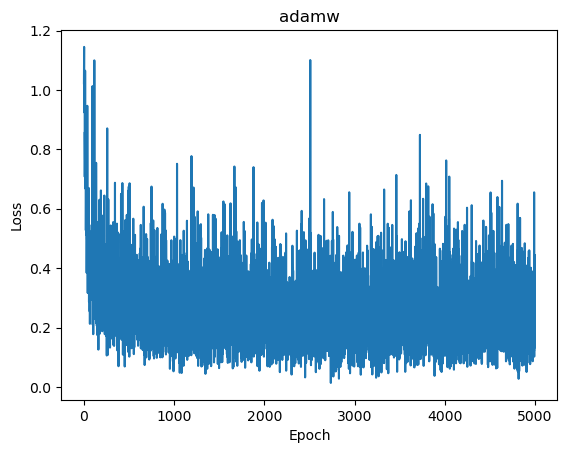

In [22]:

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(optimizer_name)

plt.show()


# DECISION BOUNDARY


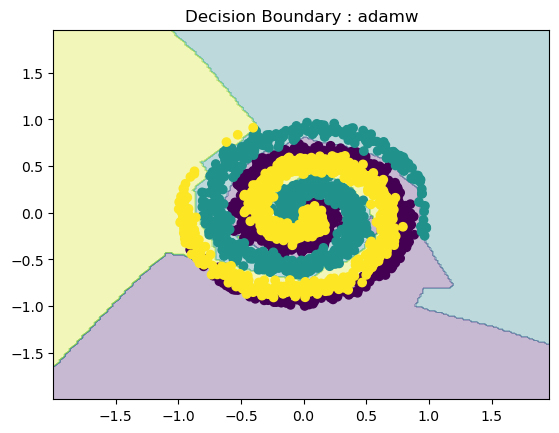

In [23]:


h = 0.02

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1

y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

pred, _ = forward(grid, params)

Z = np.argmax(pred, axis=1)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:,0], X[:,1], c=y)

plt.title(f"Decision Boundary : {optimizer_name}")

plt.show()

# Everything Put together .....

epoch=0 loss=1.0512 acc=0.4417
epoch=500 loss=0.1572 acc=0.9013
epoch=1000 loss=0.1640 acc=0.9047
epoch=1500 loss=0.2547 acc=0.9087
epoch=2000 loss=0.5010 acc=0.9043
epoch=2500 loss=0.1635 acc=0.9027
epoch=3000 loss=0.2941 acc=0.9140
epoch=3500 loss=0.0882 acc=0.9010
epoch=4000 loss=0.1817 acc=0.9077
epoch=4500 loss=0.1871 acc=0.8850


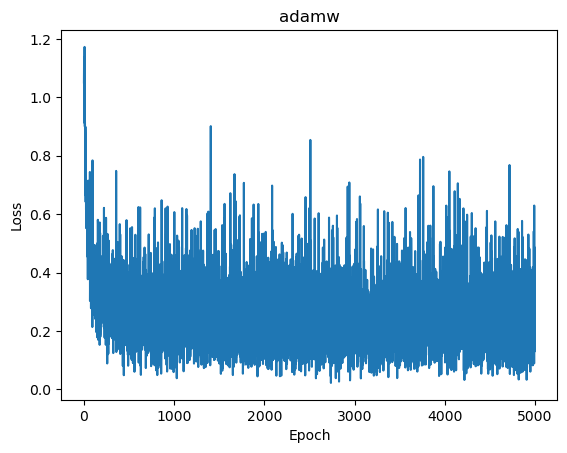

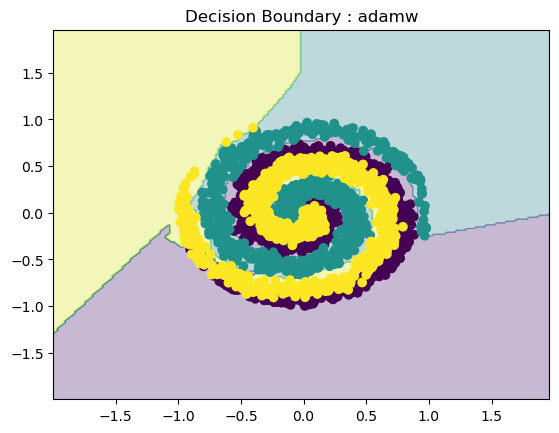

In [24]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

nnfs.init()

# ============================================================
# DATA
# ============================================================

X, y = spiral_data(samples=1000, classes=3)

# ============================================================
# ONE HOT
# ============================================================

def one_hot(y, num_classes):

    return np.eye(num_classes)[y]

y_onehot = one_hot(y, 3)

# ============================================================
# NETWORK PARAMETERS
# ============================================================

INPUT_DIM = 2
HIDDEN_DIM = 64
OUTPUT_DIM = 3

# ============================================================
# INITIALIZE PARAMETERS
# ============================================================

def init_params():

    params = {

        "W1": 0.01 * np.random.randn(INPUT_DIM, HIDDEN_DIM),
        "b1": np.zeros((1, HIDDEN_DIM)),

        "W2": 0.01 * np.random.randn(HIDDEN_DIM, OUTPUT_DIM),
        "b2": np.zeros((1, OUTPUT_DIM))
    }

    return params

# ============================================================
# ACTIVATIONS
# ============================================================

def relu(x):

    return np.maximum(0, x)

def relu_derivative(x):

    return (x > 0).astype(float)

def softmax(x):

    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# ============================================================
# FORWARD PASS
# ============================================================

def forward(X, params):

    Z1 = X @ params["W1"] + params["b1"]

    A1 = relu(Z1)

    Z2 = A1 @ params["W2"] + params["b2"]

    A2 = softmax(Z2)

    cache = {

        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

# ============================================================
# LOSS
# ============================================================

def cross_entropy(y_pred, y_true):

    y_pred = np.clip(y_pred, 1e-8, 1-1e-8)

    loss = -np.sum(y_true * np.log(y_pred)) / len(y_true)

    return loss

# ============================================================
# BACKPROP
# ============================================================

def backward(X, y_true, params, cache):

    m = len(X)

    A1 = cache["A1"]
    A2 = cache["A2"]
    Z1 = cache["Z1"]

    dZ2 = (A2 - y_true) / m

    dW2 = A1.T @ dZ2

    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ params["W2"].T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1

    db1 = np.sum(dZ1, axis=0, keepdims=True)

    grads = {

        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2
    }

    return grads

# ============================================================
# ACCURACY
# ============================================================

def accuracy(y_pred, y_true):

    pred = np.argmax(y_pred, axis=1)

    true = np.argmax(y_true, axis=1)

    return np.mean(pred == true)

# ============================================================
# OPTIMIZERS
# ============================================================

# ------------------------------------------------------------
# 1. BASIC GRADIENT DESCENT
# ------------------------------------------------------------

def update_gd(params, grads, lr):

    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"]

    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"]

# ------------------------------------------------------------
# 2. RMSPROP
# ------------------------------------------------------------

def init_rmsprop(params):

    cache = {}

    for k in params:

        cache[k] = np.zeros_like(params[k])

    return cache

def update_rmsprop(params, grads, cache, lr,
                   beta=0.9, eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        cache[p] = beta * cache[p] + \
                   (1-beta) * grads[g]**2

        params[p] -= lr * grads[g] / \
                     (np.sqrt(cache[p]) + eps)

# ------------------------------------------------------------
# 3. ADAGRAD
# ------------------------------------------------------------

def init_adagrad(params):

    cache = {}

    for k in params:

        cache[k] = np.zeros_like(params[k])

    return cache

def update_adagrad(params, grads, cache,
                   lr, eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        cache[p] += grads[g]**2

        params[p] -= lr * grads[g] / \
                     (np.sqrt(cache[p]) + eps)

# ------------------------------------------------------------
# 4. ADAM
# ------------------------------------------------------------

def init_adam(params):

    m = {}
    v = {}

    for k in params:

        m[k] = np.zeros_like(params[k])
        v[k] = np.zeros_like(params[k])

    return m, v

def update_adam(params, grads,
                m, v, t,
                lr=0.01,
                beta1=0.9,
                beta2=0.999,
                eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        m[p] = beta1 * m[p] + \
               (1-beta1) * grads[g]

        v[p] = beta2 * v[p] + \
               (1-beta2) * (grads[g]**2)

        m_hat = m[p] / (1-beta1**t)

        v_hat = v[p] / (1-beta2**t)

        params[p] -= lr * m_hat / \
                     (np.sqrt(v_hat) + eps)

# ------------------------------------------------------------
# 5. ADAMW
# ------------------------------------------------------------

def update_adamw(params, grads,
                 m, v, t,
                 lr=0.01,
                 weight_decay=1e-4,
                 beta1=0.9,
                 beta2=0.999,
                 eps=1e-8):

    for p, g in zip(
        ["W1","b1","W2","b2"],
        ["dW1","db1","dW2","db2"]
    ):

        m[p] = beta1 * m[p] + \
               (1-beta1) * grads[g]

        v[p] = beta2 * v[p] + \
               (1-beta2) * (grads[g]**2)

        m_hat = m[p] / (1-beta1**t)

        v_hat = v[p] / (1-beta2**t)

        params[p] -= lr * (
            m_hat / (np.sqrt(v_hat) + eps)
            + weight_decay * params[p]
        )

# ============================================================
# TRAINING
# ============================================================

optimizer_name = "adamw"

params = init_params()

epochs = 5000

batch_size = 32

losses = []

if optimizer_name == "rmsprop":

    cache = init_rmsprop(params)

elif optimizer_name == "adagrad":

    cache = init_adagrad(params)

elif optimizer_name in ["adam", "adamw"]:

    m, v = init_adam(params)

t = 0

for epoch in range(epochs):

    indices = np.random.permutation(len(X))

    X_shuffled = X[indices]

    y_shuffled = y_onehot[indices]

    for i in range(0, len(X), batch_size):

        X_batch = X_shuffled[i:i+batch_size]

        y_batch = y_shuffled[i:i+batch_size]

        # forward
        y_pred, cache_forward = forward(
            X_batch,
            params
        )

        # loss
        loss = cross_entropy(
            y_pred,
            y_batch
        )

        # backward
        grads = backward(
            X_batch,
            y_batch,
            params,
            cache_forward
        )

        # update
        if optimizer_name == "gd":

            update_gd(params, grads, lr=1.0)

        elif optimizer_name == "rmsprop":

            update_rmsprop(
                params,
                grads,
                cache,
                lr=0.01
            )

        elif optimizer_name == "adagrad":

            update_adagrad(
                params,
                grads,
                cache,
                lr=0.5
            )

        elif optimizer_name == "adam":

            t += 1

            update_adam(
                params,
                grads,
                m,
                v,
                t,
                lr=0.01
            )

        elif optimizer_name == "adamw":

            t += 1

            update_adamw(
                params,
                grads,
                m,
                v,
                t,
                lr=0.01
            )

    losses.append(loss)

    if epoch % 500 == 0:

        full_pred, _ = forward(X, params)

        acc = accuracy(full_pred, y_onehot)

        print(
            f"epoch={epoch} "
            f"loss={loss:.4f} "
            f"acc={acc:.4f}"
        )

# ============================================================
# LOSS CURVE
# ============================================================

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(optimizer_name)

plt.show()

# ============================================================
# DECISION BOUNDARY
# ============================================================

h = 0.02

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1

y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

pred, _ = forward(grid, params)

Z = np.argmax(pred, axis=1)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:,0], X[:,1], c=y)

plt.title(f"Decision Boundary : {optimizer_name}")

plt.show()